# Bab 1: Import Library dan Konfigurasi Path

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import PyTorch menggantikan TensorFlow/Keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Parameter
DATASET_DIR = Path("Dataset")
TARGET_WIDTH = 224
TARGET_HEIGHT = 224
BATCH_SIZE = 32
EPOCHS = 10
RANDOM_SEED = 42

# Set seed untuk reproduktibilitas di PyTorch
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Deteksi CPU atau GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

# Deteksi nama kelas
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", NUM_CLASSES)

Device yang digunakan: cuda
Kelas ditemukan: ['100k', '10k', '20k', '2k', '50k', '5k']
Jumlah kelas   : 6


# Bab 2: Fungsi Preprocessing & Augmentasi Manual

In [ ]:
def mask_hsv(image_bgr, min_area_ratio=0.01, kernel_size=7):
    if image_bgr is None:
        raise ValueError("Gambar tidak berhasil dibaca.")

    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    mask = mask | flood_inv

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    result = cv2.bitwise_and(work_img, work_img, mask=refined)
    return work_img, refined, result

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image_bgr

    x, y, w, h = cv2.boundingRect(coords)
    h_img, w_img = image_bgr.shape[:2]
    pad = int(max(w, h) * pad_ratio)

    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, w_img)
    y2 = min(y + h + pad, h_img)

    return image_bgr[y1:y2, x1:x2]

def resize_image(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)

    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2
    output[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return output

def normalize_mobilenet(image_rgb):
    # Skala menjadi [-1, 1]
    return (image_rgb.astype(np.float32) / 127.5) - 1.0

def augmentation(X_train, y_train):
    X_aug = []
    y_aug = []
    
    print("      -> Melakukan augmentasi (Flip & Rotasi)...")
    for img, label in zip(X_train, y_train):
        X_aug.append(img)
        y_aug.append(label)
        
        img_flipped = cv2.flip(img, 1) 
        X_aug.append(img_flipped)
        y_aug.append(label)
        
        angle = np.random.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        img_rotated = cv2.warpAffine(img, M, (w, h), borderValue=(-1.0, -1.0, -1.0))
        X_aug.append(img_rotated)
        y_aug.append(label)
        
    X_aug = np.array(X_aug)
    y_aug = np.array(y_aug)
    
    indices = np.arange(len(X_aug))
    np.random.shuffle(indices)
    
    return X_aug[indices], y_aug[indices]

# Bab 3: Looping Pengumpulan Data Utama

In [3]:
list_gambar = []
list_label = []

print("Memulai pembacaan dataset dan eksekusi preprocessing...")

for nama_kelas in CLASS_NAMES:
    class_path = DATASET_DIR / nama_kelas
    indeks_kelas = class_to_idx[nama_kelas]
    images_in_folder = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))]
    
    for file_img in images_in_folder:
        img_path = class_path / file_img
        img = cv2.imread(str(img_path))
        
        if img is None:
            continue
            
        _, mask, segmented = mask_hsv(img)
        cropped = crop_to_mask(segmented, mask)
        resized = resize_image(cropped, TARGET_WIDTH, TARGET_HEIGHT)
        
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        normed = normalize_mobilenet(img_rgb)
        
        list_gambar.append(normed)
        list_label.append(indeks_kelas)

X = np.array(list_gambar)
y = np.array(list_label)
# y tidak perlu di-one-hot encode. Cukup array [0, 1, 2, ...]

print(f"Total seluruh data sukses diproses: {X.shape[0]} gambar")

Memulai pembacaan dataset dan eksekusi preprocessing...
Total seluruh data sukses diproses: 192 gambar


# Bab 4: Model PyTorch dan 5-Fold Cross Validation

In [4]:
class CustomMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(CustomMobileNetV2, self).__init__()
        
        # Load pre-trained MobileNetV2
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = mobilenet.features
        
        # Freeze base model (Trainable = False)
        for param in self.features.parameters():
            param.requires_grad = False
            
        # Global Average Pooling setara di PyTorch
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Setup K-Fold
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)

rekam_akurasi_fold = []
rekam_loss_fold = []
y_asli_semua = []
y_prediksi_semua = []

os.makedirs('models', exist_ok=True)

for indeks_fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n==========================================")
    print(f" Memulai Pelatihan: FOLD KE-{indeks_fold + 1} dari {K_FOLDS}")
    print(f"==========================================")
    
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]
    
    print(f"      -> Jumlah Data Latih Sebelum Augmentasi: {len(X_train_f)}")
    X_train_f, y_train_f = augmentation(X_train_f, y_train_f)
    print(f"      -> Jumlah Data Latih Setelah Augmentasi: {len(X_train_f)}")
    
    # -------------------------------------------------------------
    # KONVERSI FORMAT NUMPY KE TENSOR PYTORCH
    # Ubah format image dari (N, H, W, C) menjadi (N, C, H, W)
    # -------------------------------------------------------------
    X_train_f = np.transpose(X_train_f, (0, 3, 1, 2))
    X_val_f = np.transpose(X_val_f, (0, 3, 1, 2))
    
    # Buat Dataset dan DataLoader
    train_dataset = TensorDataset(torch.tensor(X_train_f, dtype=torch.float32), torch.tensor(y_train_f, dtype=torch.long))
    val_dataset = TensorDataset(torch.tensor(X_val_f, dtype=torch.float32), torch.tensor(y_val_f, dtype=torch.long))
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Inisialisasi Model, Loss, dan Optimizer baru tiap fold
    model = CustomMobileNetV2(num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    # Hanya melatih parameter di layer classifier (karena fitur di-freeze)
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.0005)
    
    # --- TRAINING LOOP MANUAL PYTORCH ---
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()        # Reset gradient
            outputs = model(inputs)      # Forward pass
            loss = criterion(outputs, labels) # Hitung error
            loss.backward()              # Backward pass
            optimizer.step()             # Update weights
            
            running_loss += loss.item() * inputs.size(0)
            
        # Optional: Print progress per epoch
        # epoch_loss = running_loss / len(train_loader.dataset)
        # print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")
        
    # --- EVALUASI FOLD ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # Matikan perhitungan gradient untuk testing
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            y_prediksi_semua.extend(predicted.cpu().numpy())
            
    y_asli_semua.extend(y_val_f)
    
    fold_acc = correct / total
    fold_loss = val_loss / total
    rekam_akurasi_fold.append(fold_acc * 100)
    rekam_loss_fold.append(fold_loss)
    print(f"\nHasil Akhir Fold {indeks_fold + 1} -> Akurasi: {fold_acc*100:.2f}%, Loss: {fold_loss:.4f}")
    
    # Simpan model utama
    if indeks_fold == 0:
        # Di PyTorch, kita menyimpan state_dict() (kumpulan bobot)-nya saja
        torch.save(model.state_dict(), 'models/MobileNetV2CrossVal.pth')
        print("--> Model Fold 1 disimpan sebagai model utama (.pth).")


 Memulai Pelatihan: FOLD KE-1 dari 5
      -> Jumlah Data Latih Sebelum Augmentasi: 153
      -> Melakukan augmentasi (Flip & Rotasi)...
      -> Jumlah Data Latih Setelah Augmentasi: 459


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\ROG FLOWX13/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:02<00:00, 5.11MB/s]



Hasil Akhir Fold 1 -> Akurasi: 97.44%, Loss: 0.1944
--> Model Fold 1 disimpan sebagai model utama (.pth).

 Memulai Pelatihan: FOLD KE-2 dari 5
      -> Jumlah Data Latih Sebelum Augmentasi: 153
      -> Melakukan augmentasi (Flip & Rotasi)...
      -> Jumlah Data Latih Setelah Augmentasi: 459

Hasil Akhir Fold 2 -> Akurasi: 97.44%, Loss: 0.1959

 Memulai Pelatihan: FOLD KE-3 dari 5
      -> Jumlah Data Latih Sebelum Augmentasi: 154
      -> Melakukan augmentasi (Flip & Rotasi)...
      -> Jumlah Data Latih Setelah Augmentasi: 462

Hasil Akhir Fold 3 -> Akurasi: 100.00%, Loss: 0.1578

 Memulai Pelatihan: FOLD KE-4 dari 5
      -> Jumlah Data Latih Sebelum Augmentasi: 154
      -> Melakukan augmentasi (Flip & Rotasi)...
      -> Jumlah Data Latih Setelah Augmentasi: 462

Hasil Akhir Fold 4 -> Akurasi: 100.00%, Loss: 0.1527

 Memulai Pelatihan: FOLD KE-5 dari 5
      -> Jumlah Data Latih Sebelum Augmentasi: 154
      -> Melakukan augmentasi (Flip & Rotasi)...
      -> Jumlah Data Latih 

# Bab 5: Rekapitulasi Nilai Rata-Rata Cross Validation & Laporan Akhir


   RINGKASAN K-FOLD CROSS VALIDATION
• Fold ke-1 : Akurasi = 97.44% | Loss = 0.1944
• Fold ke-2 : Akurasi = 97.44% | Loss = 0.1959
• Fold ke-3 : Akurasi = 100.00% | Loss = 0.1578
• Fold ke-4 : Akurasi = 100.00% | Loss = 0.1527
• Fold ke-5 : Akurasi = 97.37% | Loss = 0.1939
------------------------------------------
👉 RATA-RATA AKURASI K-FOLD : 98.45%
👉 RATA-RATA LOSS K-FOLD    : 0.1789

📊 LAPORAN KLASIFIKASI GLOBAL (AKUMULASI 5-FOLD):

              precision    recall  f1-score   support

        100k       1.00      0.97      0.98        32
         10k       0.97      1.00      0.98        32
         20k       1.00      0.97      0.98        32
          2k       1.00      1.00      1.00        32
         50k       0.97      1.00      0.98        32
          5k       0.97      0.97      0.97        32

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



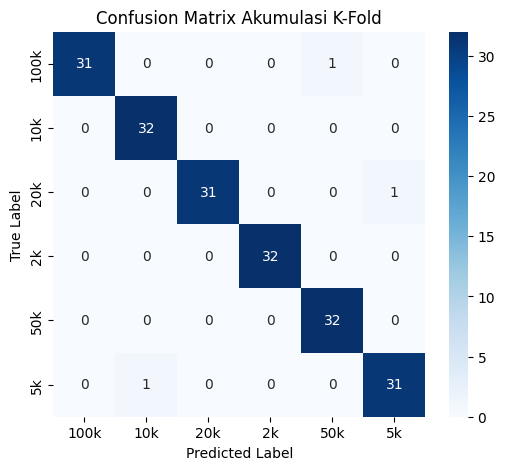

In [5]:
print("\n==========================================")
print("   RINGKASAN K-FOLD CROSS VALIDATION")
print("==========================================")
for i in range(K_FOLDS):
    print(f"• Fold ke-{i+1} : Akurasi = {rekam_akurasi_fold[i]:.2f}% | Loss = {rekam_loss_fold[i]:.4f}")
print("-" * 42)
print(f"👉 RATA-RATA AKURASI K-FOLD : {np.mean(rekam_akurasi_fold):.2f}%")
print(f"👉 RATA-RATA LOSS K-FOLD    : {np.mean(rekam_loss_fold):.4f}")

# Laporan Klasifikasi
y_asli_semua = np.array(y_asli_semua)
y_prediksi_semua = np.array(y_prediksi_semua)

print("\n📊 LAPORAN KLASIFIKASI GLOBAL (AKUMULASI 5-FOLD):\n")
print(classification_report(y_asli_semua, y_prediksi_semua, target_names=CLASS_NAMES, zero_division=0))

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_asli_semua, y_prediksi_semua), annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix Akumulasi K-Fold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Bab 6: Prediksi Gambar Baru (Data Unseen)

✅ Model berhasil dimuat dari penyimpan lokal!


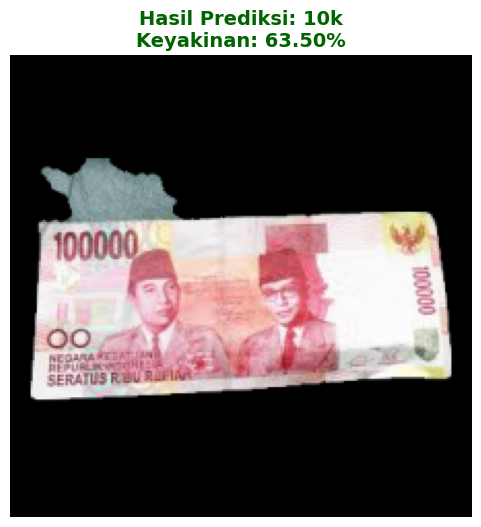

👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '10k' (63.50%).


In [8]:
PATH_GAMBAR_BARU = "tester100k.png" 
path_model_saved = 'models/MobileNetV2CrossVal.pth'

if os.path.exists(path_model_saved):
    # Buat instance model kosong, lalu isi dengan bobot yang disimpan
    model_demo = CustomMobileNetV2(num_classes=NUM_CLASSES).to(device)
    model_demo.load_state_dict(torch.load(path_model_saved, map_location=device))
    model_demo.eval() # Set ke mode evaluation
    print("✅ Model berhasil dimuat dari penyimpan lokal!")
else:
    print("❌ File model tidak ditemukan!")
    model_demo = None

if model_demo is not None:
    img_bgr_baru = cv2.imread(PATH_GAMBAR_BARU)

    if img_bgr_baru is None:
        print(f"❌ Gagal membaca gambar {PATH_GAMBAR_BARU}!")
    else:
        _, mask_baru, segmented_baru = mask_hsv(img_bgr_baru)
        cropped_baru = crop_to_mask(segmented_baru, mask_baru)
        resized_baru = resize_image(cropped_baru, TARGET_WIDTH, TARGET_HEIGHT)
        img_rgb_baru = cv2.cvtColor(resized_baru, cv2.COLOR_BGR2RGB)
        
        normed_baru = normalize_mobilenet(img_rgb_baru)

        # PyTorch format (C, H, W) -> (3, 224, 224)
        input_transposed = np.transpose(normed_baru, (2, 0, 1))
        # Tambah batch dimension (1, 3, 224, 224)
        input_tensor = torch.tensor(input_transposed, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model_demo(input_tensor)
            # Hitung persentase softmax karena model hanya mereturn logit
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            skor_tertinggi, prediksi = torch.max(probabilities, 1)
            
            indeks_tertinggi = prediksi.item()
            persen_keyakinan = skor_tertinggi.item() * 100
        
        nama_prediksi = CLASS_NAMES[indeks_tertinggi]

        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb_baru)
        plt.title(f"Hasil Prediksi: {nama_prediksi}\nKeyakinan: {persen_keyakinan:.2f}%", fontsize=14, fontweight='bold', color='darkgreen')
        plt.axis('off')
        plt.show()

        print(f"👉 Kesimpulan: Model mendeteksi gambar tersebut sebagai pecahan '{nama_prediksi}' ({persen_keyakinan:.2f}%).")